# Question 2: Winner Prediction Using Question 3 Clusters And History Games

This notebook uses the **Question 3 player archetype clusters** together with **pre-game history features** to predict who is more likely to win a matchup.

Because Question 2 is about opening-repertoire advantage among roughly equal players, this notebook keeps the same equal-Elo framing and adds cluster-level style information from Question 3.


## Modeling Idea
1. Load the cleaned game dataset from `dataset/final_data`.
2. Load the player archetype assignments from `Question_three/output/player_archetypes.csv`.
3. Build pre-game history features so each row only uses information available before the game happened.
4. Merge each player's Question 3 cluster and archetype.
5. Train a multiclass model to predict `white_win`, `draw`, or `black_win`.


## Important Assumption
This notebook uses the final Question 3 cluster assignment per player as a stable player-style summary. That is useful for your project, but it does mean the cluster labels were learned from the full player sample rather than recomputed before each game date.


In [1]:
import os
import warnings
from collections import Counter, defaultdict
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, log_loss
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


In [2]:
DATA_PATH = Path('/Users/phamhoanghai/Ureca/dataset/final_data')
Q3_CLUSTER_PATH = Path('/Users/phamhoanghai/Ureca/Question_three/output/player_archetypes.csv')
OUTPUT_DIR = Path('/Users/phamhoanghai/Ureca/Question_two/cluster_history_output')
PLOT_DIR = Path('/Users/phamhoanghai/Ureca/Question_two/cluster_history_plots')

MIN_TOTAL_GAMES_PER_PLAYER = 20
MIN_HISTORY_GAMES = 10
ELO_TOLERANCE = 25
TEST_SIZE_FRACTION = 0.20
RANDOM_STATE = 42

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(DATA_PATH)
print(Q3_CLUSTER_PATH)


/Users/phamhoanghai/Ureca/dataset/final_data
/Users/phamhoanghai/Ureca/Question_three/output/player_archetypes.csv


In [3]:
raw_df = pd.read_csv(DATA_PATH)
clusters_df = pd.read_csv(Q3_CLUSTER_PATH)

print('Raw data shape:', raw_df.shape)
print('Cluster data shape:', clusters_df.shape)
clusters_df.head()


Raw data shape: (1111082, 13)
Cluster data shape: (12888, 27)


,player,games_played,avg_elo,mean_score,opening_diversity,favorite_opening,favorite_opening_games,favorite_opening_share,favorite_openings_coverage,family_closed_share,family_flank_share,family_indian_share,family_open_share,family_semi_open_share,eco_a_share,eco_b_share,eco_c_share,eco_d_share,eco_e_share,attackish_share,defensive_share,positional_share,hypermodern_share,cluster_id,archetype,pca_1,pca_2
0,aavza50,4531,1633.904215,0.529133,172,Van't Kruijs Opening,1182,0.260870,0.484882,0.0,1.000000,0.0,0.0,0.000000,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,Hypermodern Strategists,-3.617478,-2.162431
1,faryad22,3091,1843.109026,0.489486,169,Hungarian Opening,792,0.256228,0.431252,0.0,1.000000,0.0,0.0,0.000000,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.240810,0.000000,0,Hypermodern Strategists,-3.759813,-1.834430
2,igo1,3031,2118.773012,0.604751,262,King's Indian Attack,219,0.072253,0.185087,0.0,0.629234,0.0,0.0,0.370766,0.629234,0.370766,0.0,0.0,0.0,0.390374,0.370766,0.370766,0.390374,0,Hypermodern Strategists,-1.983678,1.579394
3,ribarisah,2956,2072.632612,0.467185,235,Hungarian Opening,323,0.109269,0.251691,0.0,0.856183,0.0,0.0,0.143817,0.856183,0.143817,0.0,0.0,0.0,0.250000,0.315860,0.000000,0.565860,0,Hypermodern Strategists,-2.875107,0.199008
4,nizzle_fe_shizzle,2801,1933.652624,0.710104,67,Modern Defense,546,0.194930,0.381292,0.0,0.771536,0.0,0.0,0.228464,0.771536,0.228464,0.0,0.0,0.0,0.488764,0.511236,0.181648,0.818352,0,Hypermodern Strategists,-3.578862,0.011208


## Standardize Match Data


In [4]:
def map_result_to_label(result_series: pd.Series) -> pd.Series:
    s = result_series.astype(str).str.strip()
    mapping = {
        '1-0': 'white_win',
        '0-1': 'black_win',
        '1/2-1/2': 'draw',
        '0.5-0.5': 'draw',
        '1': 'white_win',
        '0': 'black_win',
        '0.5': 'draw',
        'win': 'white_win',
        'loss': 'black_win',
        'draw': 'draw',
    }
    return s.map(mapping)


def standardize_games(df: pd.DataFrame) -> pd.DataFrame:
    keep_cols = [
        'GameID', 'White', 'Black', 'WhiteEloNumeric', 'BlackEloNumeric',
        'Opening', 'OpeningFamily', 'Result'
    ]
    out = df[keep_cols].copy()
    out.columns = [
        'game_id', 'white_player', 'black_player', 'white_elo', 'black_elo',
        'opening_name', 'opening_family', 'result'
    ]
    out['game_id'] = pd.to_numeric(out['game_id'], errors='coerce')
    out['white_elo'] = pd.to_numeric(out['white_elo'], errors='coerce')
    out['black_elo'] = pd.to_numeric(out['black_elo'], errors='coerce')
    out['winner_label'] = map_result_to_label(out['result'])
    out = out.dropna(subset=['game_id', 'white_player', 'black_player', 'white_elo', 'black_elo', 'opening_name', 'winner_label'])
    out = out.sort_values(['game_id', 'white_player', 'black_player'], kind='mergesort').reset_index(drop=True)
    out['elo_diff'] = out['white_elo'] - out['black_elo']
    out['abs_elo_diff'] = out['elo_diff'].abs()
    out['avg_elo'] = (out['white_elo'] + out['black_elo']) / 2
    return out

games_df = standardize_games(raw_df)
print(games_df.shape)
games_df.head()


(1111082, 12)


,game_id,white_player,black_player,white_elo,black_elo,opening_name,opening_family,result,winner_label,elo_diff,abs_elo_diff,avg_elo
0,1,sisy,lpaulmp,1645.0,1449.0,Queen's Gambit Declined: Queen's Knight Variation,Closed and Semi-Closed,1-0,white_win,196.0,196.0,1547.0
1,2,capablanca1950,ftri67,1603.0,1672.0,French Defense,Open Games and Semi-Open,0-1,black_win,-69.0,69.0,1637.5
2,3,daamien,mike81,1166.0,1280.0,Queen's Pawn Game: Steinitz Countergambit,Closed and Semi-Closed,1-0,white_win,-114.0,114.0,1223.0
3,4,yaavarmo,JACKELCALVO,1494.0,1449.0,French Defense: Normal Variation,Open Games and Semi-Open,1-0,white_win,45.0,45.0,1471.5
4,5,albinofrenchy,galita,1256.0,1285.0,Queen's Gambit Declined: 4.Bg5 Be7,Closed and Semi-Closed,1-0,white_win,-29.0,29.0,1270.5


## Build Pre-Game History Features
Only earlier games are used to describe each player's prior form and repertoire consistency.


In [5]:
def shannon_entropy_from_counter(counter: Counter) -> float:
    total = sum(counter.values())
    if total == 0:
        return np.nan
    probs = np.array(list(counter.values()), dtype=float) / total
    return float(-(probs * np.log2(probs)).sum())


def extract_top_item(counter: Counter):
    if not counter:
        return 'Unknown', 0
    item, count = max(counter.items(), key=lambda kv: (kv[1], kv[0]))
    return item, count


def opposite_winner_label(label: str) -> str:
    if label == 'white_win':
        return 'black_win'
    if label == 'black_win':
        return 'white_win'
    return 'draw'


def build_history_features(df: pd.DataFrame) -> pd.DataFrame:
    player_stats = defaultdict(lambda: {
        'games': 0,
        'openings': Counter(),
        'families': Counter(),
        'results': Counter(),
    })
    matchup_counts = Counter()
    rows = []

    for row in df.itertuples(index=False):
        white_stats = player_stats[row.white_player]
        black_stats = player_stats[row.black_player]
        matchup_key = tuple(sorted((row.white_player, row.black_player)))

        white_top_opening, white_top_opening_games = extract_top_item(white_stats['openings'])
        black_top_opening, black_top_opening_games = extract_top_item(black_stats['openings'])
        white_top_family, white_top_family_games = extract_top_item(white_stats['families'])
        black_top_family, black_top_family_games = extract_top_item(black_stats['families'])

        white_games = white_stats['games']
        black_games = black_stats['games']

        white_win_rate = white_stats['results']['white_win'] / white_games if white_games else np.nan
        black_win_rate = black_stats['results']['white_win'] / black_games if black_games else np.nan
        white_draw_rate = white_stats['results']['draw'] / white_games if white_games else np.nan
        black_draw_rate = black_stats['results']['draw'] / black_games if black_games else np.nan
        white_loss_rate = white_stats['results']['black_win'] / white_games if white_games else np.nan
        black_loss_rate = black_stats['results']['black_win'] / black_games if black_games else np.nan

        rows.append({
            'game_id': row.game_id,
            'white_player': row.white_player,
            'black_player': row.black_player,
            'white_elo': row.white_elo,
            'black_elo': row.black_elo,
            'avg_elo': row.avg_elo,
            'elo_diff': row.elo_diff,
            'abs_elo_diff': row.abs_elo_diff,
            'opening_name': row.opening_name,
            'opening_family': row.opening_family,
            'winner_label': row.winner_label,
            'prior_matchups': matchup_counts[matchup_key],
            'white_history_games': white_games,
            'black_history_games': black_games,
            'white_unique_openings': len(white_stats['openings']),
            'black_unique_openings': len(black_stats['openings']),
            'white_unique_families': len(white_stats['families']),
            'black_unique_families': len(black_stats['families']),
            'white_opening_entropy': shannon_entropy_from_counter(white_stats['openings']),
            'black_opening_entropy': shannon_entropy_from_counter(black_stats['openings']),
            'white_family_entropy': shannon_entropy_from_counter(white_stats['families']),
            'black_family_entropy': shannon_entropy_from_counter(black_stats['families']),
            'white_top_opening': white_top_opening,
            'black_top_opening': black_top_opening,
            'white_top_family': white_top_family,
            'black_top_family': black_top_family,
            'white_top_opening_share': white_top_opening_games / white_games if white_games else np.nan,
            'black_top_opening_share': black_top_opening_games / black_games if black_games else np.nan,
            'white_top_family_share': white_top_family_games / white_games if white_games else np.nan,
            'black_top_family_share': black_top_family_games / black_games if black_games else np.nan,
            'white_prior_win_rate': white_win_rate,
            'black_prior_win_rate': black_win_rate,
            'white_prior_draw_rate': white_draw_rate,
            'black_prior_draw_rate': black_draw_rate,
            'white_prior_loss_rate': white_loss_rate,
            'black_prior_loss_rate': black_loss_rate,
            'same_top_opening': int(white_top_opening == black_top_opening and white_top_opening != 'Unknown'),
            'same_top_family': int(white_top_family == black_top_family and white_top_family != 'Unknown'),
        })

        white_stats['games'] += 1
        black_stats['games'] += 1
        white_stats['openings'][row.opening_name] += 1
        black_stats['openings'][row.opening_name] += 1
        white_stats['families'][row.opening_family] += 1
        black_stats['families'][row.opening_family] += 1
        white_stats['results'][row.winner_label] += 1
        black_stats['results'][opposite_winner_label(row.winner_label)] += 1
        matchup_counts[matchup_key] += 1

    out = pd.DataFrame(rows)
    out['history_games_gap'] = out['white_history_games'] - out['black_history_games']
    out['opening_diversity_gap'] = out['white_unique_openings'] - out['black_unique_openings']
    out['family_diversity_gap'] = out['white_unique_families'] - out['black_unique_families']
    out['opening_entropy_gap'] = out['white_opening_entropy'] - out['black_opening_entropy']
    out['family_entropy_gap'] = out['white_family_entropy'] - out['black_family_entropy']
    out['opening_focus_gap'] = out['white_top_opening_share'] - out['black_top_opening_share']
    out['family_focus_gap'] = out['white_top_family_share'] - out['black_top_family_share']
    out['prior_win_rate_gap'] = out['white_prior_win_rate'] - out['black_prior_win_rate']
    out['prior_draw_rate_gap'] = out['white_prior_draw_rate'] - out['black_prior_draw_rate']
    out['prior_loss_rate_gap'] = out['white_prior_loss_rate'] - out['black_prior_loss_rate']
    return out

player_counts = pd.concat([games_df['white_player'], games_df['black_player']], ignore_index=True).value_counts()
frequent_players = player_counts[player_counts >= MIN_TOTAL_GAMES_PER_PLAYER].index
frequent_games_df = games_df[
    games_df['white_player'].isin(frequent_players)
    & games_df['black_player'].isin(frequent_players)
].copy()

history_df = build_history_features(frequent_games_df)
print(history_df.shape)
history_df.head()


(1025440, 48)


,game_id,white_player,black_player,white_elo,black_elo,avg_elo,elo_diff,abs_elo_diff,opening_name,opening_family,winner_label,prior_matchups,white_history_games,black_history_games,white_unique_openings,black_unique_openings,white_unique_families,black_unique_families,white_opening_entropy,black_opening_entropy,white_family_entropy,black_family_entropy,white_top_opening,black_top_opening,white_top_family,black_top_family,white_top_opening_share,black_top_opening_share,white_top_family_share,black_top_family_share,white_prior_win_rate,black_prior_win_rate,white_prior_draw_rate,black_prior_draw_rate,white_prior_loss_rate,black_prior_loss_rate,same_top_opening,same_top_family,history_games_gap,opening_diversity_gap,family_diversity_gap,opening_entropy_gap,family_entropy_gap,opening_focus_gap,family_focus_gap,prior_win_rate_gap,prior_draw_rate_gap,prior_loss_rate_gap
0,1,sisy,lpaulmp,1645.0,1449.0,1547.0,196.0,196.0,Queen's Gambit Declined: Queen's Knight Variation,Closed and Semi-Closed,white_win,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,capablanca1950,ftri67,1603.0,1672.0,1637.5,-69.0,69.0,French Defense,Open Games and Semi-Open,black_win,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,daamien,mike81,1166.0,1280.0,1223.0,-114.0,114.0,Queen's Pawn Game: Steinitz Countergambit,Closed and Semi-Closed,white_win,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,yaavarmo,JACKELCALVO,1494.0,1449.0,1471.5,45.0,45.0,French Defense: Normal Variation,Open Games and Semi-Open,white_win,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,albinofrenchy,galita,1256.0,1285.0,1270.5,-29.0,29.0,Queen's Gambit Declined: 4.Bg5 Be7,Closed and Semi-Closed,white_win,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Merge Question 3 Cluster Features


In [6]:
cluster_cols = [
    'player', 'cluster_id', 'archetype', 'mean_score', 'opening_diversity',
    'favorite_opening_share', 'favorite_openings_coverage', 'attackish_share',
    'defensive_share', 'positional_share', 'hypermodern_share'
]
cluster_features = clusters_df[cluster_cols].copy()

white_cluster = cluster_features.rename(columns={
    'player': 'white_player',
    'cluster_id': 'white_cluster_id',
    'archetype': 'white_archetype',
    'mean_score': 'white_cluster_mean_score',
    'opening_diversity': 'white_cluster_opening_diversity',
    'favorite_opening_share': 'white_cluster_favorite_share',
    'favorite_openings_coverage': 'white_cluster_top3_coverage',
    'attackish_share': 'white_cluster_attackish_share',
    'defensive_share': 'white_cluster_defensive_share',
    'positional_share': 'white_cluster_positional_share',
    'hypermodern_share': 'white_cluster_hypermodern_share',
})

black_cluster = cluster_features.rename(columns={
    'player': 'black_player',
    'cluster_id': 'black_cluster_id',
    'archetype': 'black_archetype',
    'mean_score': 'black_cluster_mean_score',
    'opening_diversity': 'black_cluster_opening_diversity',
    'favorite_opening_share': 'black_cluster_favorite_share',
    'favorite_openings_coverage': 'black_cluster_top3_coverage',
    'attackish_share': 'black_cluster_attackish_share',
    'defensive_share': 'black_cluster_defensive_share',
    'positional_share': 'black_cluster_positional_share',
    'hypermodern_share': 'black_cluster_hypermodern_share',
})

cluster_history_df = history_df.merge(white_cluster, on='white_player', how='left').merge(black_cluster, on='black_player', how='left')
cluster_history_df['same_cluster'] = (cluster_history_df['white_cluster_id'] == cluster_history_df['black_cluster_id']).astype(int)
cluster_history_df['same_archetype'] = (cluster_history_df['white_archetype'] == cluster_history_df['black_archetype']).astype(int)
cluster_history_df['cluster_mean_score_gap'] = cluster_history_df['white_cluster_mean_score'] - cluster_history_df['black_cluster_mean_score']
cluster_history_df['cluster_diversity_gap'] = cluster_history_df['white_cluster_opening_diversity'] - cluster_history_df['black_cluster_opening_diversity']
cluster_history_df['cluster_favorite_share_gap'] = cluster_history_df['white_cluster_favorite_share'] - cluster_history_df['black_cluster_favorite_share']
cluster_history_df['cluster_top3_coverage_gap'] = cluster_history_df['white_cluster_top3_coverage'] - cluster_history_df['black_cluster_top3_coverage']
cluster_history_df['cluster_attackish_gap'] = cluster_history_df['white_cluster_attackish_share'] - cluster_history_df['black_cluster_attackish_share']
cluster_history_df['cluster_defensive_gap'] = cluster_history_df['white_cluster_defensive_share'] - cluster_history_df['black_cluster_defensive_share']
cluster_history_df['cluster_positional_gap'] = cluster_history_df['white_cluster_positional_share'] - cluster_history_df['black_cluster_positional_share']
cluster_history_df['cluster_hypermodern_gap'] = cluster_history_df['white_cluster_hypermodern_share'] - cluster_history_df['black_cluster_hypermodern_share']
cluster_history_df['cluster_matchup'] = cluster_history_df['white_archetype'].fillna('Unknown') + ' vs ' + cluster_history_df['black_archetype'].fillna('Unknown')

print(cluster_history_df.shape)
cluster_history_df[['white_player','black_player','white_archetype','black_archetype','winner_label']].head()


(1025440, 79)


,white_player,black_player,white_archetype,black_archetype,winner_label
0,sisy,lpaulmp,Counterpunching Defenders,Hypermodern Strategists,white_win
1,capablanca1950,ftri67,Counterpunching Defenders,Hypermodern Strategists,black_win
2,daamien,mike81,Positional Defenders,Aggressive Attackers,white_win
3,yaavarmo,JACKELCALVO,Aggressive Attackers,Hypermodern Strategists,white_win
4,albinofrenchy,galita,Counterpunching Defenders,Aggressive Attackers,white_win


## Keep Equal-Elo First-Time Matchups For Question 2


In [7]:
model_df = cluster_history_df[
    (cluster_history_df['prior_matchups'] == 0)
    & (cluster_history_df['white_history_games'] >= MIN_HISTORY_GAMES)
    & (cluster_history_df['black_history_games'] >= MIN_HISTORY_GAMES)
    & (cluster_history_df['abs_elo_diff'] <= ELO_TOLERANCE)
    & cluster_history_df['white_cluster_id'].notna()
    & cluster_history_df['black_cluster_id'].notna()
].copy()

print('Model rows:', len(model_df))
print(model_df['winner_label'].value_counts(dropna=False))
model_df.head()


Model rows: 68959
winner_label
white_win    33987
black_win    31950
draw          3022
Name: count, dtype: int64


,game_id,white_player,black_player,white_elo,black_elo,avg_elo,elo_diff,abs_elo_diff,opening_name,opening_family,winner_label,prior_matchups,white_history_games,black_history_games,white_unique_openings,black_unique_openings,white_unique_families,black_unique_families,white_opening_entropy,black_opening_entropy,white_family_entropy,black_family_entropy,white_top_opening,black_top_opening,white_top_family,black_top_family,white_top_opening_share,black_top_opening_share,white_top_family_share,black_top_family_share,white_prior_win_rate,black_prior_win_rate,white_prior_draw_rate,black_prior_draw_rate,white_prior_loss_rate,black_prior_loss_rate,same_top_opening,same_top_family,history_games_gap,opening_diversity_gap,family_diversity_gap,opening_entropy_gap,family_entropy_gap,opening_focus_gap,family_focus_gap,prior_win_rate_gap,prior_draw_rate_gap,prior_loss_rate_gap,white_cluster_id,white_archetype,white_cluster_mean_score,white_cluster_opening_diversity,white_cluster_favorite_share,white_cluster_top3_coverage,white_cluster_attackish_share,white_cluster_defensive_share,white_cluster_positional_share,white_cluster_hypermodern_share,black_cluster_id,black_archetype,black_cluster_mean_score,black_cluster_opening_diversity,black_cluster_favorite_share,black_cluster_top3_coverage,black_cluster_attackish_share,black_cluster_defensive_share,black_cluster_positional_share,black_cluster_hypermodern_share,same_cluster,same_archetype,cluster_mean_score_gap,cluster_diversity_gap,cluster_favorite_share_gap,cluster_top3_coverage_gap,cluster_attackish_gap,cluster_defensive_gap,cluster_positional_gap,cluster_hypermodern_gap,cluster_matchup
1691,1899,Zzorro,bombozik,1722.0,1740.0,1731.0,-18.0,18.0,French Defense: Two Knights Variation,Open Games and Semi-Open,black_win,0,17,33,16,18,4,4,3.969816,3.819959,1.865437,1.661882,Vienna Game: Max Lange Defense,Queen's Pawn Game #2,Semi-Open Defenses,Flank Openings,0.117647,0.212121,0.352941,0.454545,0.176471,0.242424,0.176471,0.151515,0.647059,0.606061,0,0,-16,-2,0,0.149857,0.203555,-0.094474,-0.101604,-0.065954,0.024955,0.040998,1,Aggressive Attackers,0.462239,179,0.088913,0.214247,0.000000,0.735000,0.000000,0.000000,0,Hypermodern Strategists,0.483446,228,0.092031,0.221661,0.000000,0.415190,0.0,0.207595,0,0,-0.021207,-49,-0.003119,-0.007414,0.000000,0.319810,0.000000,-0.207595,Aggressive Attackers vs Hypermodern Strategists
2344,2629,INTIWATANA,patrick03,1551.0,1569.0,1560.0,-18.0,18.0,Scandinavian Defense: Modern Variation #2,Semi-Open Defenses,white_win,0,25,21,22,17,3,4,4.323856,4.011365,1.461901,1.717041,Englund Gambit Complex: Englund Gambit,Van't Kruijs Opening,Open Games and Semi-Open,Open Games and Semi-Open,0.160000,0.095238,0.480000,0.428571,0.480000,0.380952,0.080000,0.047619,0.440000,0.571429,0,1,4,5,-1,0.312491,-0.255140,0.064762,0.051429,0.099048,0.032381,-0.131429,1,Aggressive Attackers,0.588235,81,0.071895,0.143791,0.500000,0.500000,0.000000,0.000000,0,Hypermodern Strategists,0.429641,282,0.132834,0.244383,0.229032,0.227419,0.0,0.000000,0,0,0.158594,-201,-0.060939,-0.100592,0.270968,0.272581,0.000000,0.000000,Aggressive Attackers vs Hypermodern Strategists
2893,3281,grasshopper,cocochess,1830.0,1811.0,1820.5,19.0,19.0,Sicilian Defense: Smith-Morra Gambit #2,Semi-Open Defenses,black_win,0,18,14,14,10,3,3,3.614369,3.182006,1.122114,0.946373,Modern Defense,Sicilian Defense #2,Semi-Open Defenses,Semi-Open Defenses,0.222222,0.214286,0.722222,0.785714,0.611111,0.714286,0.055556,0.000000,0.333333,0.285714,0,1,4,4,0,0.432364,0.175741,0.007937,-0.063492,-0.103175,0.055556,0.047619,0,Hypermodern Strategists,0.552004,139,0.213434,0.461538,0.000000,0.580595,0.000000,0.580595,2,Counterpunching Defenders,0.669671,383,0.068182,0.133229,0.000000,0.743529,0.0,0.511765,0,0,-0.117667,-244,0.145253,0.328310,0.000000,-0.162935,0.000000,0.068830,Hypermodern Strategists vs Counterpunching Def...
2950,3347,Laisha,shuntandromeda1,1622.0,1636.0,1629.0,-14.0,14.0,Horwitz Defense,Flank Openings,black_win,0,12,21,8,

## Feature Set
This model uses:
- pre-game history features
- Question 3 cluster and archetype features
- cluster matchup patterns


In [8]:
NUM_FEATURES = [
    'avg_elo',
    'abs_elo_diff',
    'white_history_games',
    'black_history_games',
    'history_games_gap',
    'white_unique_openings',
    'black_unique_openings',
    'opening_diversity_gap',
    'white_unique_families',
    'black_unique_families',
    'family_diversity_gap',
    'white_opening_entropy',
    'black_opening_entropy',
    'opening_entropy_gap',
    'white_family_entropy',
    'black_family_entropy',
    'family_entropy_gap',
    'white_top_opening_share',
    'black_top_opening_share',
    'opening_focus_gap',
    'white_top_family_share',
    'black_top_family_share',
    'family_focus_gap',
    'white_prior_win_rate',
    'black_prior_win_rate',
    'prior_win_rate_gap',
    'white_prior_draw_rate',
    'black_prior_draw_rate',
    'prior_draw_rate_gap',
    'white_prior_loss_rate',
    'black_prior_loss_rate',
    'prior_loss_rate_gap',
    'same_top_opening',
    'same_top_family',
    'white_cluster_id',
    'black_cluster_id',
    'same_cluster',
    'same_archetype',
    'white_cluster_mean_score',
    'black_cluster_mean_score',
    'cluster_mean_score_gap',
    'white_cluster_opening_diversity',
    'black_cluster_opening_diversity',
    'cluster_diversity_gap',
    'white_cluster_favorite_share',
    'black_cluster_favorite_share',
    'cluster_favorite_share_gap',
    'white_cluster_top3_coverage',
    'black_cluster_top3_coverage',
    'cluster_top3_coverage_gap',
    'white_cluster_attackish_share',
    'black_cluster_attackish_share',
    'cluster_attackish_gap',
    'white_cluster_defensive_share',
    'black_cluster_defensive_share',
    'cluster_defensive_gap',
    'white_cluster_positional_share',
    'black_cluster_positional_share',
    'cluster_positional_gap',
    'white_cluster_hypermodern_share',
    'black_cluster_hypermodern_share',
    'cluster_hypermodern_gap',
]

CAT_FEATURES = [
    'white_archetype',
    'black_archetype',
    'white_top_opening',
    'black_top_opening',
    'white_top_family',
    'black_top_family',
    'cluster_matchup',
]

TARGET_COL = 'winner_label'
CLASS_ORDER = ['white_win', 'draw', 'black_win']


## Chronological Train/Test Split


In [9]:
model_df = model_df.sort_values('game_id').reset_index(drop=True)
split_idx = int(len(model_df) * (1 - TEST_SIZE_FRACTION))
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

print('Train rows:', len(train_df))
print('Test rows:', len(test_df))
print(train_df[TARGET_COL].value_counts(normalize=True))
print(test_df[TARGET_COL].value_counts(normalize=True))


Train rows: 55167
Test rows: 13792
winner_label
white_win    0.493121
black_win    0.462505
draw         0.044374
Name: proportion, dtype: float64
winner_label
white_win    0.491807
black_win    0.466575
draw         0.041618
Name: proportion, dtype: float64


## Prepare Model Matrix
We use scaled numeric features and one-hot encoded categorical matchup features.


In [10]:
num_imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_num = pd.DataFrame(
    scaler.fit_transform(num_imputer.fit_transform(train_df[NUM_FEATURES])),
    columns=NUM_FEATURES,
    index=train_df.index,
)
X_test_num = pd.DataFrame(
    scaler.transform(num_imputer.transform(test_df[NUM_FEATURES])),
    columns=NUM_FEATURES,
    index=test_df.index,
)

X_train_cat = pd.get_dummies(train_df[CAT_FEATURES].fillna('Unknown'), prefix=CAT_FEATURES)
X_test_cat = pd.get_dummies(test_df[CAT_FEATURES].fillna('Unknown'), prefix=CAT_FEATURES)
X_train_cat, X_test_cat = X_train_cat.align(X_test_cat, join='outer', axis=1, fill_value=0)

X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

y_train = train_df[TARGET_COL].copy()
y_test = test_df[TARGET_COL].copy()

label_encoder = LabelEncoder()
label_encoder.fit(CLASS_ORDER)
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print('Train matrix shape:', X_train.shape)
print('Test matrix shape:', X_test.shape)


Train matrix shape: (55167, 1821)
Test matrix shape: (13792, 1821)


## Train Winner Prediction Model


In [11]:

val_split_idx = int(len(X_train) * 0.85)
X_subtrain = X_train.iloc[:val_split_idx]
X_val = X_train.iloc[val_split_idx:]
y_subtrain = y_train_encoded[:val_split_idx]
y_val = y_train_encoded[val_split_idx:]

param_grid = {
    'learning_rate': [0.03, 0.05],
    'max_depth': [4, 6, None],
    'max_leaf_nodes': [31, 63],
    'min_samples_leaf': [20, 40],
    'l2_regularization': [0.0, 0.1],
}

search_rows = []
best_params = None
best_loss = float('inf')

for params in ParameterGrid(param_grid):
    model = HistGradientBoostingClassifier(
        loss='log_loss',
        max_iter=300,
        early_stopping=True,
        validation_fraction=None,
        random_state=RANDOM_STATE,
        **params,
    )
    model.fit(X_subtrain, y_subtrain)
    val_pred = model.predict_proba(X_val)
    val_loss = log_loss(y_val, val_pred, labels=np.arange(len(CLASS_ORDER)))
    search_rows.append({**params, 'val_log_loss': float(val_loss)})

    if val_loss < best_loss:
        best_loss = val_loss
        best_params = params

search_df = pd.DataFrame(search_rows).sort_values('val_log_loss').reset_index(drop=True)
print('Best params:', best_params)
print('Best validation log loss:', round(best_loss, 5))

search_df.head(10)


Best params: {'l2_regularization': 0.0, 'learning_rate': 0.03, 'max_depth': 4, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}
Best validation log loss: 0.82835


,l2_regularization,learning_rate,max_depth,max_leaf_nodes,min_samples_leaf,val_log_loss
0,0.0,0.03,4.0,31,20,0.828349
1,0.0,0.03,4.0,63,20,0.828349
2,0.1,0.03,4.0,31,20,0.828466
3,0.1,0.03,4.0,63,20,0.828466
4,0.1,0.03,4.0,31,40,0.828671
5,0.1,0.03,4.0,63,40,0.828671
6,0.0,0.03,4.0,31,40,0.828936
7,0.0,0.03,4.0,63,40,0.828936
8,0.0,0.03,6.0,31,20,0.830143
9,0.1,0.05,4.0,31,20,0.830274


In [12]:
final_model = HistGradientBoostingClassifier(
    loss='log_loss',
    max_iter=400,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_STATE,
    **best_params,
)
final_model.fit(X_train, y_train_encoded)

test_pred_proba = final_model.predict_proba(X_test)
test_pred = final_model.predict(X_test)
test_pred_labels = label_encoder.inverse_transform(test_pred)

model_log_loss = log_loss(y_test_encoded, test_pred_proba, labels=np.arange(len(CLASS_ORDER)))
conf_mat = confusion_matrix(y_test, test_pred_labels, labels=CLASS_ORDER)

prob_df = pd.DataFrame(test_pred_proba, columns=[f'prob_{c}' for c in label_encoder.classes_], index=test_df.index)
results_df = pd.concat([
    test_df[['game_id', 'white_player', 'black_player', 'white_archetype', 'black_archetype', 'winner_label']].reset_index(drop=True),
    pd.Series(test_pred_labels, name='predicted_winner_label'),
    prob_df.reset_index(drop=True),
], axis=1)

print('Test log loss:', round(model_log_loss, 5))
print(classification_report(y_test, test_pred_labels, labels=CLASS_ORDER))
results_df.head()


Test log loss: 0.82122
              precision    recall  f1-score   support

   white_win       0.54      0.73      0.62      6783
        draw       0.00      0.00      0.00       574
   black_win       0.57      0.41      0.47      6435

    accuracy                           0.55     13792
   macro avg       0.37      0.38      0.37     13792
weighted avg       0.53      0.55      0.53     13792



,game_id,white_player,black_player,white_archetype,black_archetype,winner_label,predicted_winner_label,prob_black_win,prob_draw,prob_white_win
0,899603,alecool2,babak48,Aggressive Attackers,Aggressive Attackers,black_win,white_win,0.482653,0.029781,0.487566
1,899625,ogun,alab,Aggressive Attackers,Counterpunching Defenders,white_win,white_win,0.440190,0.029439,0.530372
2,899650,formatc,nik59,Counterpunching Defenders,Counterpunching Defenders,black_win,white_win,0.465516,0.026309,0.508175
3,899660,Hei,TransCanadaHighway,Aggressive Attackers,Positional Defenders,black_win,black_win,0.522297,0.046147,0.431556
4,899671,persepolis46,elfomen,Positional Defenders,Hypermodern Strategists,white_win,black_win,0.506814,0.042507,0.450680


## Which Cluster + History Signals Matter Most?


In [13]:
baseline_loss = log_loss(y_test_encoded, test_pred_proba, labels=np.arange(len(CLASS_ORDER)))
importance_features = [
    'history_games_gap',
    'opening_diversity_gap',
    'opening_entropy_gap',
    'prior_win_rate_gap',
    'family_focus_gap',
    'same_cluster',
    'same_archetype',
    'cluster_mean_score_gap',
    'cluster_diversity_gap',
    'cluster_favorite_share_gap',
    'cluster_attackish_gap',
    'cluster_defensive_gap',
    'cluster_positional_gap',
    'cluster_hypermodern_gap',
]

rng = np.random.default_rng(RANDOM_STATE)
importance_rows = []

for feature in importance_features:
    X_perm = X_test.copy()
    shuffled = X_perm[feature].to_numpy().copy()
    rng.shuffle(shuffled)
    X_perm[feature] = shuffled
    perm_pred = final_model.predict_proba(X_perm)
    perm_loss = log_loss(y_test_encoded, perm_pred, labels=np.arange(len(CLASS_ORDER)))
    importance_rows.append({
        'feature': feature,
        'log_loss_increase': float(perm_loss - baseline_loss),
    })

importance_df = pd.DataFrame(importance_rows).sort_values('log_loss_increase', ascending=False).reset_index(drop=True)
importance_df


,feature,log_loss_increase
0,cluster_mean_score_gap,3.672598e-02
1,prior_win_rate_gap,5.438452e-03
2,history_games_gap,6.722049e-04
3,opening_diversity_gap,5.129845e-04
4,cluster_hypermodern_gap,1.102620e-04
5,family_focus_gap,8.321213e-05
6,cluster_attackish_gap,6.869359e-05
7,cluster_diversity_gap,5.146130e-05
8,cluster_positional_gap,4.414999e-05
9,opening_entropy_gap,2.367198e-05


## Visual Evaluation


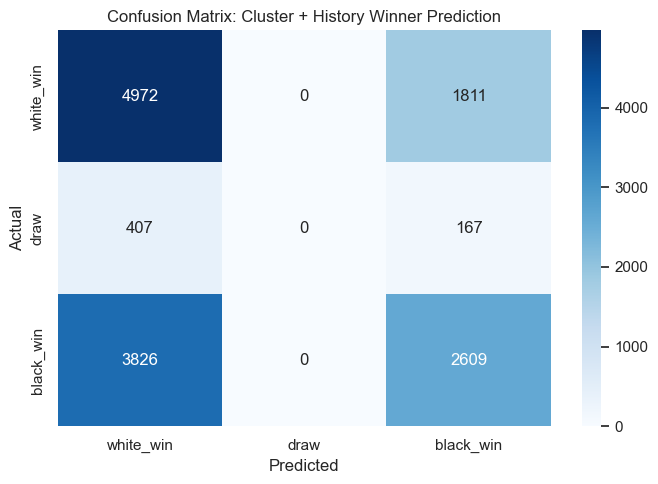

In [14]:
plt.figure(figsize=(7, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
plt.title('Confusion Matrix: Cluster + History Winner Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


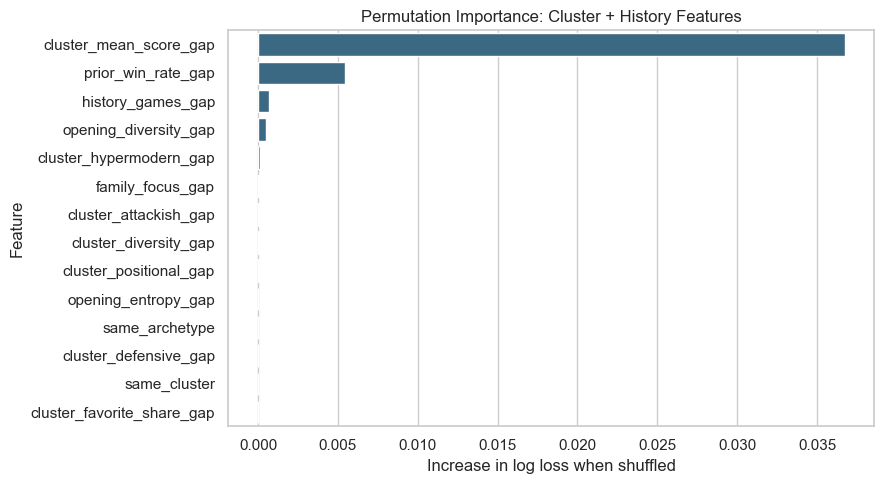

In [15]:
plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='log_loss_increase', y='feature', color='#2f6c8f')
plt.title('Permutation Importance: Cluster + History Features')
plt.xlabel('Increase in log loss when shuffled')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## Save Outputs


In [16]:
results_df.to_csv(OUTPUT_DIR / 'cluster_history_test_predictions.csv', index=False)
importance_df.to_csv(OUTPUT_DIR / 'cluster_history_permutation_importance.csv', index=False)
search_df.to_csv(OUTPUT_DIR / 'cluster_history_model_search.csv', index=False)
train_df.to_csv(OUTPUT_DIR / 'cluster_history_train_dataset.csv', index=False)
test_df.to_csv(OUTPUT_DIR / 'cluster_history_test_dataset.csv', index=False)

summary_metrics = pd.DataFrame({
    'metric': ['test_log_loss'],
    'value': [model_log_loss],
})
summary_metrics.to_csv(OUTPUT_DIR / 'cluster_history_summary_metrics.csv', index=False)

plt.figure(figsize=(7, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
plt.title('Confusion Matrix: Cluster + History Winner Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'cluster_history_confusion_matrix.png', dpi=200)
plt.close()

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='log_loss_increase', y='feature', color='#2f6c8f')
plt.title('Permutation Importance: Cluster + History Features')
plt.xlabel('Increase in log loss when shuffled')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'cluster_history_permutation_importance.png', dpi=200)
plt.close()

print('Saved outputs to:')
print(OUTPUT_DIR)
print(PLOT_DIR)


Saved outputs to:
/Users/phamhoanghai/Ureca/Question_two/cluster_history_output
/Users/phamhoanghai/Ureca/Question_two/cluster_history_plots


In [17]:
summary_metrics


,metric,value
0,test_log_loss,0.82122
